In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u

import cogsworth
from cosmic.evolve import Evolve
from cosmic.sample import InitialBinaryTable
from cosmic.utils import parse_inifile

fs = 24
style_params = {
    'font.family': 'serif',
    'text.usetex': False,
    'figure.figsize': (12, 8),
    'axes.titlesize': 24,
    'legend.title_fontsize': 18,
    'legend.fontsize': 16,
    'axes.labelsize': 24,
    'xtick.labelsize': 21,
    'ytick.labelsize': 21,
    'axes.linewidth': 1.1,
    'xtick.major.size': 7,
    'xtick.minor.size': 4,
    'ytick.major.size': 7,
    'ytick.minor.size': 4,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
}
plt.rcParams.update(style_params)

%config InlineBackend.figure_format = 'retina'

In [14]:
stats = pd.read_hdf("../helpers/zams_he_relations.h5", key="sse")

23
65.5, he_zams_mass, 23.0
65.5, ms_lifetime, 4.1
65.5, f336w_mag, 15.1
11.5
36.1, he_zams_mass, 11.5
36.1, ms_lifetime, 5.7
36.1, f336w_mag, 16.2


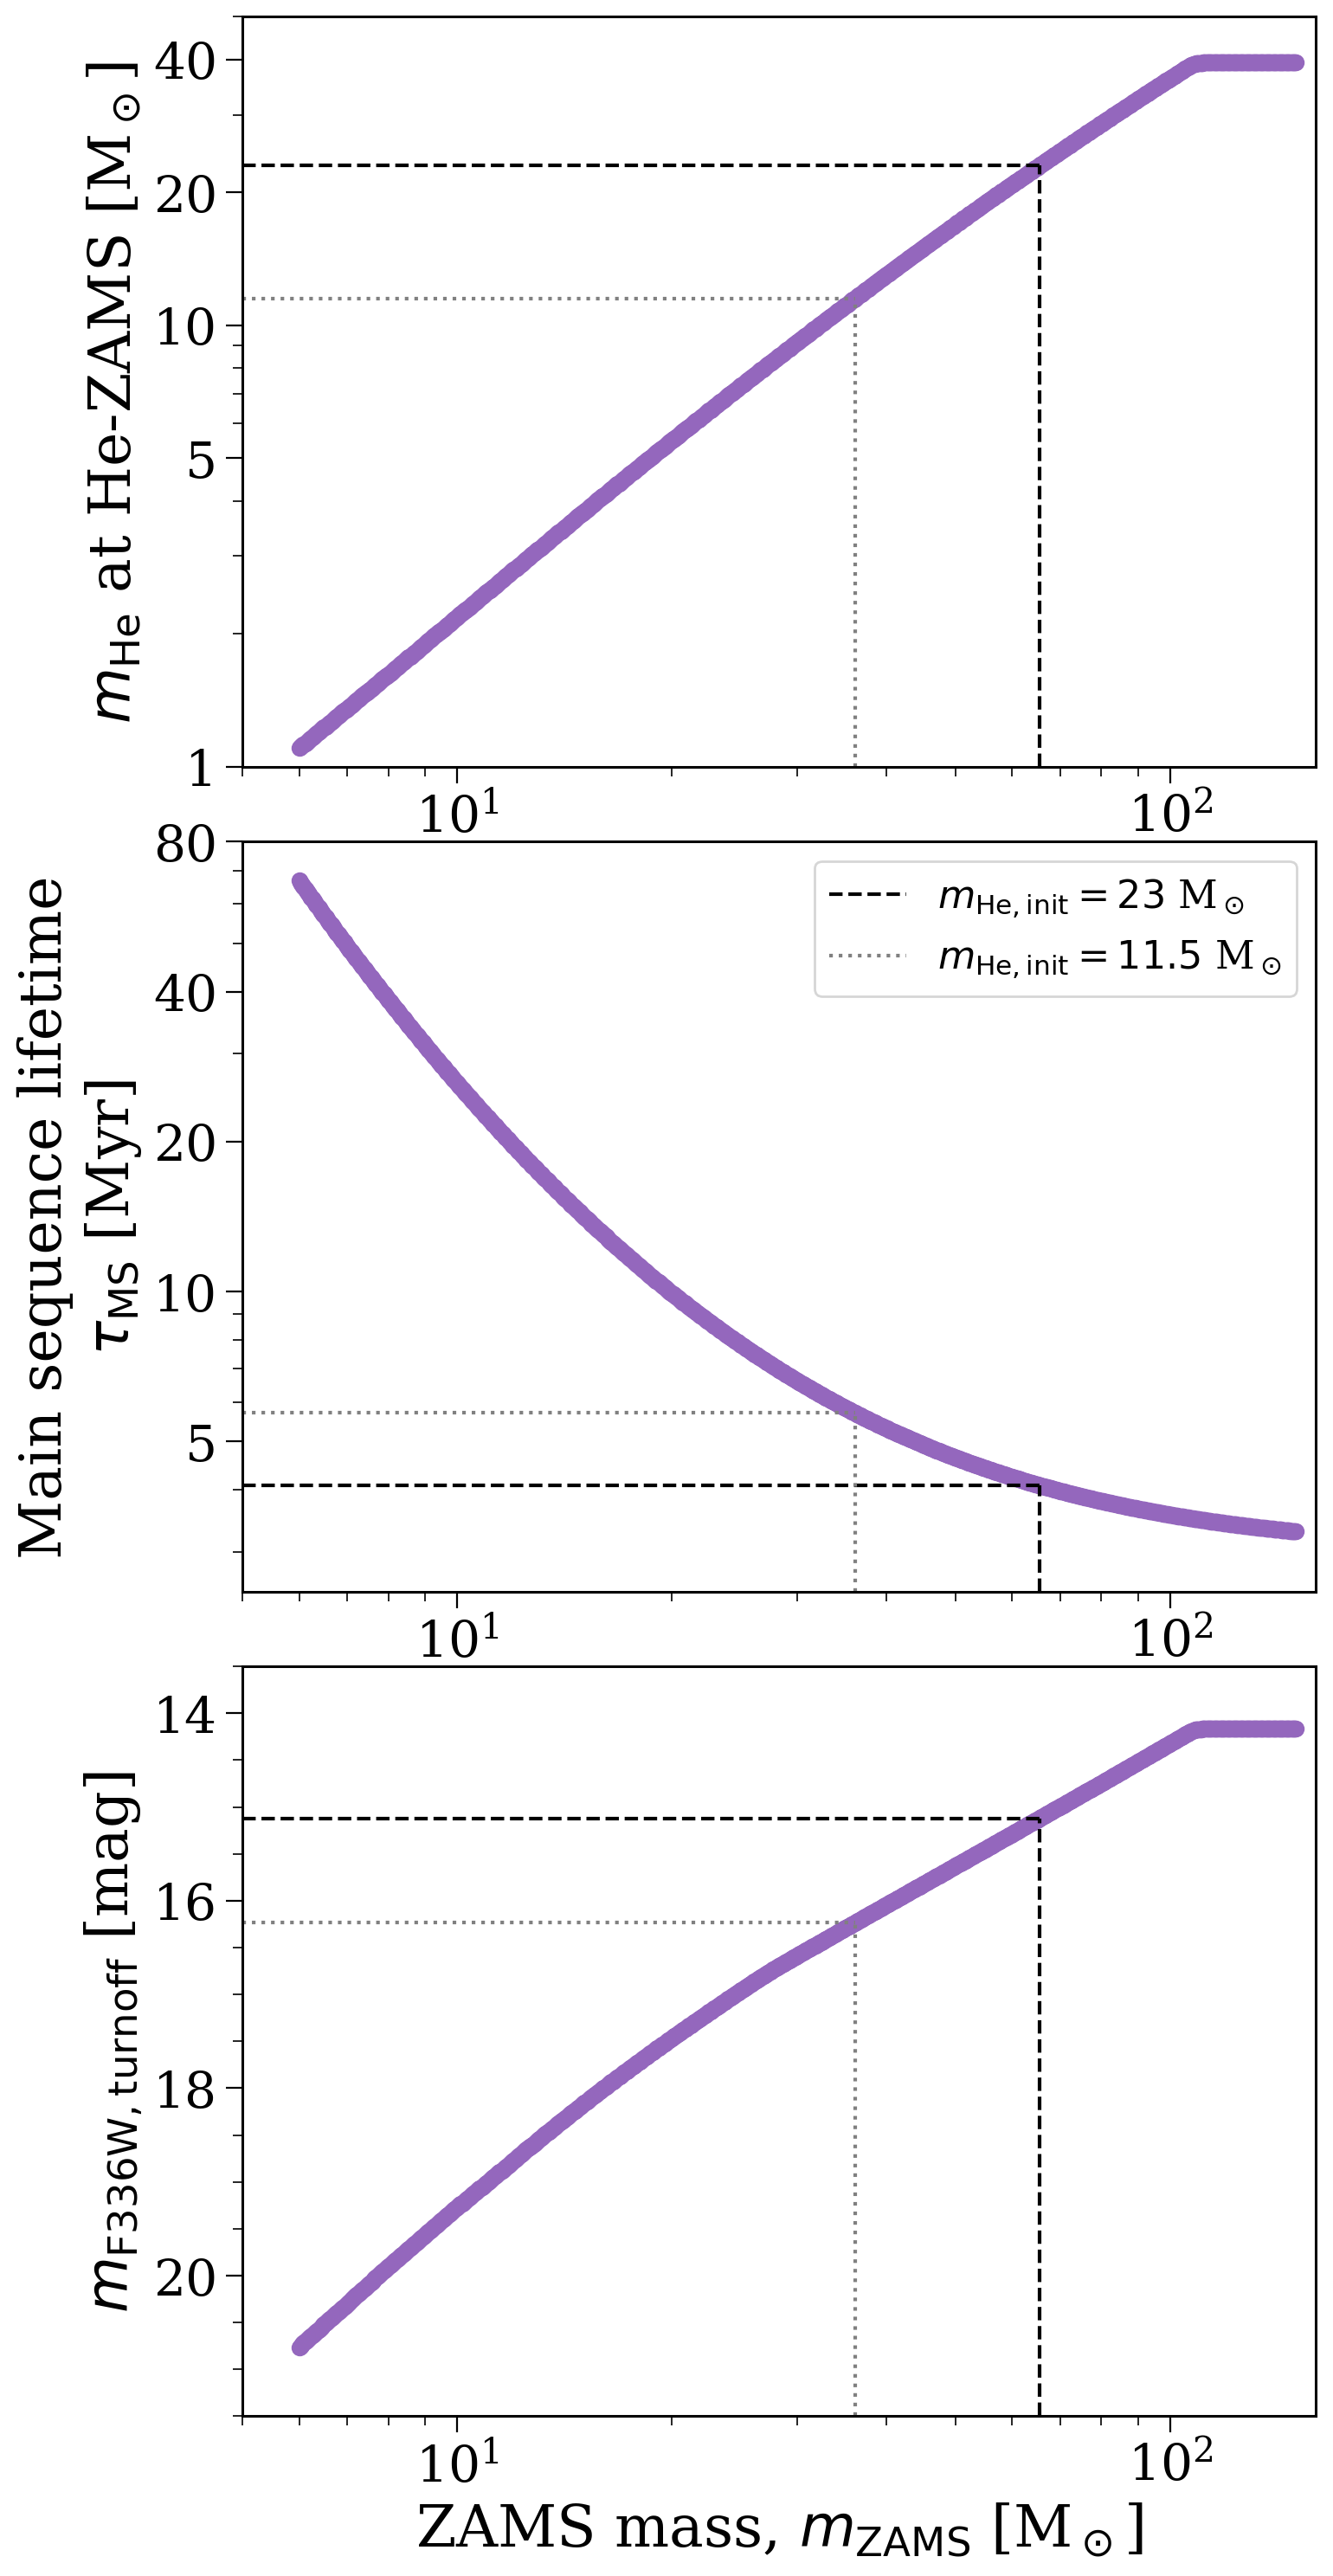

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

fig.subplots_adjust(hspace=0.1)

xlim = (5, 160)
ylims = [
    (1, 50),
    (2.5, 80),
    (21.5, 13.5)
]

axes[0].scatter(stats["zams_mass"], stats["he_zams_mass"], color="tab:purple", rasterized=True)
axes[0].set(
    xscale="log",
    yscale="log",
    ylabel=r"$m_{\rm He}$ at He-ZAMS [M$_\odot$]",
    yticks=[1, 5, 10, 20, 40],
    yticklabels=[1, 5, 10, 20, 40]
)

axes[1].scatter(stats["zams_mass"], stats["ms_lifetime"], color="tab:purple", rasterized=True)
axes[1].set(
    xscale="log",
    yscale="log",
    ylabel="Main sequence lifetime\n" + r"$\tau_{\rm MS}$ [Myr]",
    yticks=[2, 5, 10, 20, 40, 80],
    yticklabels=[2, 5, 10, 20, 40, 80]
)

axes[2].scatter(stats["zams_mass"], stats["f336w_mag"], color="tab:purple", rasterized=True)
axes[2].set(
    xscale="log",
    ylabel=r"$m_{\rm F336W, turnoff}$ [mag]",
)

for val, c, ls, label in zip([23, 23/2], ["black", "grey"], ["--", ":"], [r"$m_{\rm He, init} = 23$ M$_\odot$", r"$m_{\rm He, init} = 11.5$ M$_\odot$"]):
    closest = np.abs(stats["he_zams_mass"] - val).argmin()

    print(val)
    for ax, ylim, y_name in zip(axes, ylims, ["he_zams_mass", "ms_lifetime", "f336w_mag"]):
        print(f'{stats["zams_mass"].iloc[closest]:1.1f}, {y_name}, {stats[y_name].iloc[closest]:1.1f}')

        ax.plot([xlim[0], stats["zams_mass"].iloc[closest]],
                    [stats[y_name].iloc[closest], stats[y_name].iloc[closest]],
                    color=c, ls=ls, label=label)
        ax.plot([stats["zams_mass"].iloc[closest], stats["zams_mass"].iloc[closest]],
                    [ylim[0], stats[y_name].iloc[closest]],
                    color=c, ls=ls)
        ax.set(
            xlim=xlim,
            ylim=ylim,
        )

axes[2].set(xlabel=r"ZAMS mass, $m_{\rm ZAMS}$ [M$_\odot$]")
axes[1].legend()

fig.align_labels()

plt.savefig("../figures/zams_he_relations.pdf", bbox_inches="tight", dpi=300)

plt.show()

In [22]:
stats["post_ms_lifetime"][np.abs(stats["zams_mass"] - 65).argmin()]

np.float64(0.42709560884130404)

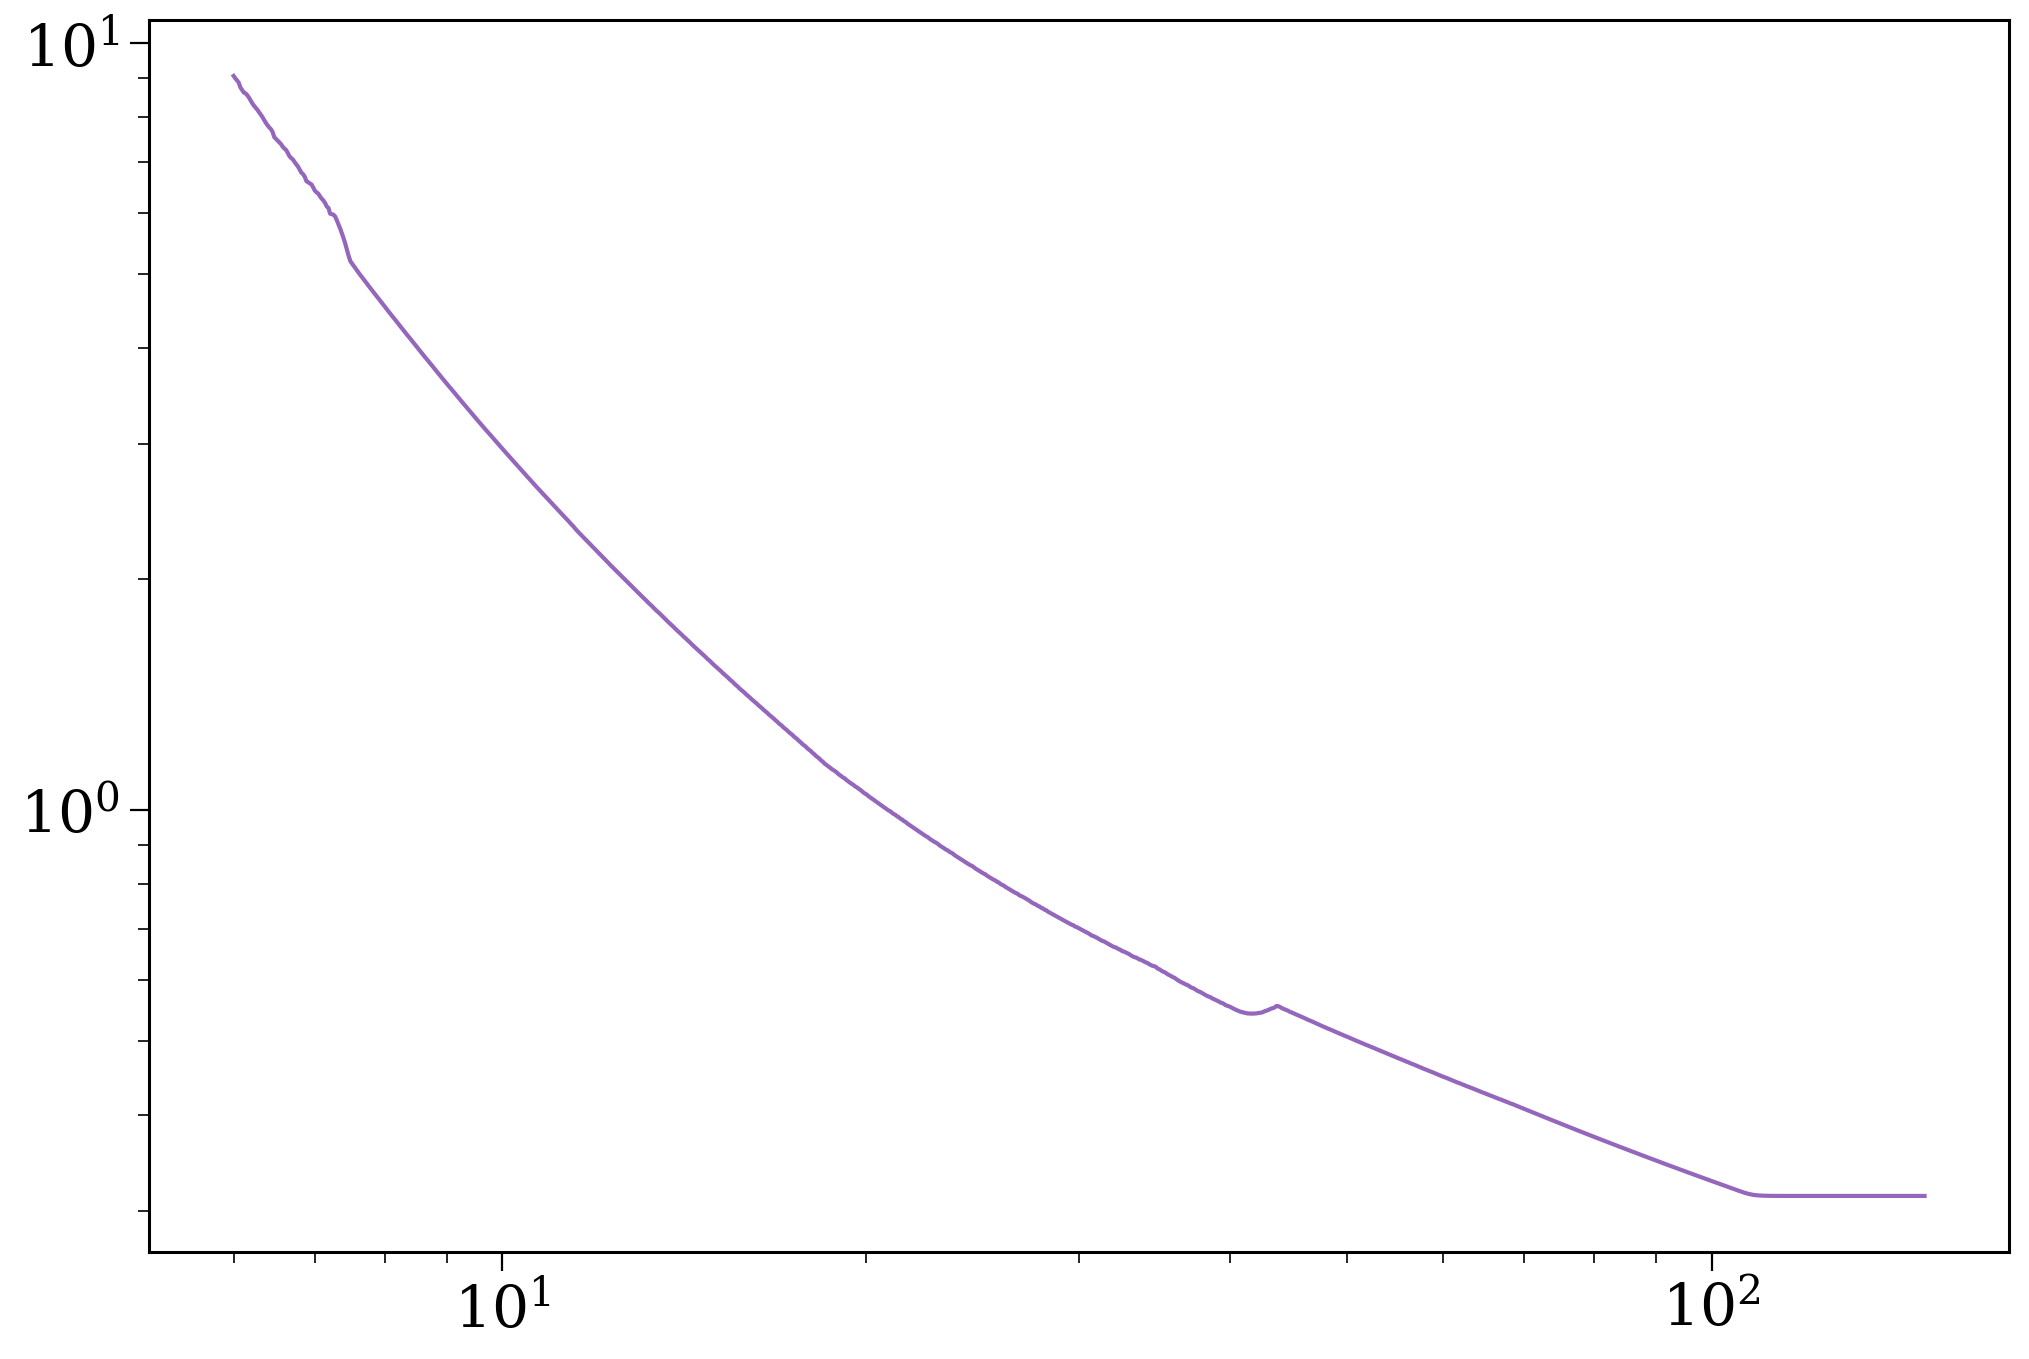

In [20]:
plt.loglog(
    stats["zams_mass"], stats["post_ms_lifetime"], color="tab:purple", rasterized=True
)